### Check a different bitcoin dataset with 3.61M rows (2012 - 2021)

In [1]:
import pandas as pd
from datasets import load_dataset

In [2]:
ds = load_dataset("Onegai/BitcoinPrice")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200', 'EMA_5', 'EMA_25', 'EMA_50', 'RSI_14', 'RSI_50', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'ADX_14', 'DMN_14', 'DMP_14', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0', 'BBB_5_2.0', 'BBP_5_2.0', 'CCI_14_0.015', 'CDL2CROWS', 'CDL3BLACKCROWS', 'CDL3INSIDE', 'CDL3LINESTRIKE', 'CDL3OUTSIDE', 'CDL3STARSINSOUTH', 'CDL3WHITESOLDIERS', 'CDLABANDONEDBABY', 'CDLADVANCEBLOCK', 'CDLBELTHOLD', 'CDLBREAKAWAY', 'CDLCLOSINGMARUBOZU', 'CDLCONCEALBABYSWALL', 'CDLCOUNTERATTACK', 'CDLDARKCLOUDCOVER', 'CDLDOJI', 'CDLDOJISTAR', 'CDLDRAGONFLYDOJI', 'CDLENGULFING', 'CDLEVENINGDOJISTAR', 'CDLEVENINGSTAR', 'CDLGAPSIDESIDEWHITE', 'CDLGRAVESTONEDOJI', 'CDLHAMMER', 'CDLHANGINGMAN', 'CDLHARAMI', 'CDLHARAMICROSS', 'CDLHIGHWAVE', 'CDLHIKKAKE', 'CDLHIKKAKEMOD', 'CDLHOMINGPIGEON', 'CDLIDENTICAL3CROWS', 'CDLINNECK', 'CDLINVERTEDHAMMER', 'CDLKICKING', 'CDLKICKINGB

In [4]:
df = ds['train'].to_pandas()

In [5]:
df

,timestamp,open,high,low,close,volume,SMA_10,SMA_20,SMA_50,SMA_100,...,CDLSTICKSANDWICH,CDLTAKURI,CDLTASUKIGAP,CDLTHRUSTING,CDLTRISTAR,CDLUNIQUE3RIVER,CDLUPSIDEGAP2CROWS,CDLXSIDEGAP3METHODS,target,__index_level_0__
0,1326463560,7.35,7.35,6.86,6.86,1.457726,6.907,6.9535,7.0854,6.9432,...,0,0,0,0,0,0,0,0,1,19094
1,1326463620,7.36,7.36,7.36,7.36,1.081522,6.973,6.9590,7.0886,6.9544,...,0,0,0,0,0,0,0,0,0,19095
2,1326464760,7.00,7.00,6.90,6.90,1.455604,6.993,6.9415,7.0826,6.9610,...,0,0,0,0,0,0,0,0,0,19114
3,1326464880,6.90,6.90,6.90,6.90,0.544396,7.013,6.9175,7.0766,6.9676,...,0,0,0,0,0,0,0,0,0,19116
4,1326465060,6.90,6.90,6.90,6.90,1.000000,7.033,6.8945,7.0706,6.9742,...,0,0,0,0,0,0,0,0,0,19119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3613564,1617148500,58742.18,58742.18,58714.31,58714.31,2.519999,58683.326,58652.6000,58667.0044,58718.0671,...,0,0,0,0,0,0,0,0,0,4857371
3613565,1617148560,58714.31,58714.31,58686.00,58686.00,1.384487,58691.926,58653.4125,58668.2668,58716.0880,...,0,0,0,0,0,0,0,0,0,4857372
3613566,1617148620,58683.97,58693.43,58683.97,58685.81,7.294848,58693.853,58656.2910,58669.3232,58714.1739,...,0,0,0,0,0,0,0,0,1,4857373
3613567,1617148680,58693.43,58723.84,58693.43,58723.84,1.705682,58695.958,58660.3595,58671.8638,58712.4673,...,0,0,0,0,0,0,0,0,1,4857374


In [6]:
# Data filtering
df['date'] = pd.to_datetime(df['timestamp'], unit="s")
# df['date'] = df['date'].dt.ceil('h')
df = df.sort_values(by='date', ascending=True)
df.set_index('date', inplace=True)
df = df[['open', 'high', 'low', 'close', 'volume']]

df.head()

,open,high,low,close,volume
date,,,,,
2012-01-13 14:06:00,7.35,7.35,6.86,6.86,1.457726
2012-01-13 14:07:00,7.36,7.36,7.36,7.36,1.081522
2012-01-13 14:26:00,7.00,7.00,6.90,6.90,1.455604
2012-01-13 14:28:00,6.90,6.90,6.90,6.90,0.544396
2012-01-13 14:31:00,6.90,6.90,6.90,6.90,1.000000


In [7]:
df.tail()

,open,high,low,close,volume
date,,,,,
2021-03-30 23:55:00,58742.18,58742.18,58714.31,58714.31,2.519999
2021-03-30 23:56:00,58714.31,58714.31,58686.00,58686.00,1.384487
2021-03-30 23:57:00,58683.97,58693.43,58683.97,58685.81,7.294848
2021-03-30 23:58:00,58693.43,58723.84,58693.43,58723.84,1.705682
2021-03-30 23:59:00,58742.18,58770.38,58742.18,58760.59,0.720415


In [8]:
df.count()

open      3613569
high      3613569
low       3613569
close     3613569
volume    3613569
dtype: int64

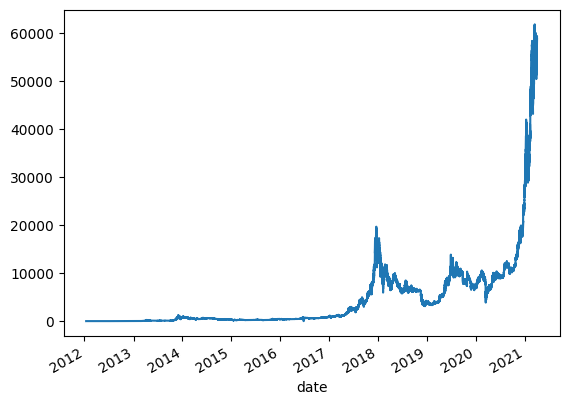

In [9]:
df['close'].plot();

### Crypto news dataset checking 

In [10]:
ds = load_dataset("SahandNZ/cryptonews-articles-with-price-momentum-labels")

In [11]:
ds

DatasetDict({
    train: Dataset({
        features: ['datetime', 'text', 'url', 'label'],
        num_rows: 144276
    })
    validation: Dataset({
        features: ['datetime', 'text', 'url', 'label'],
        num_rows: 18034
    })
    test: Dataset({
        features: ['datetime', 'text', 'url', 'label'],
        num_rows: 18035
    })
})

In [12]:
df = ds['train'].to_pandas()
df

,datetime,text,url,label
0,2022-10-14,despite fact blockchainbased carbon credit mar...,https://cryptonews.com/news/bitcoin-price-and-...,1
1,2022-10-14,trader gained huge kudos space predicting drop...,https://cryptonews.com/news/bitcoin-price-pred...,1
2,2022-10-14,always worked sticking plan clear invalidation...,https://cryptonews.com/news/bitcoin-price-pred...,1
3,2022-10-14,fact broke level system giving bullish signals...,https://cryptonews.com/news/bitcoin-price-pred...,1
4,2022-10-14,demand coming confirms theres fuel keep going ...,https://cryptonews.com/news/bitcoin-price-pred...,1
...,...,...,...,...
144271,2023-03-01,bitcoins ferocious january price rally launche...,https://cryptonews.com/news/the-bitcoin-market...,1
144272,2023-03-01,bitcoins realized price last around 19850 acco...,https://cryptonews.com/news/the-bitcoin-market...,1
144273,2023-03-01,bitcoin prices relationship realized price mea...,https://cryptonews.com/news/the-bitcoin-market...,1
144274,2023-03-01,metrics sending unified signal mediumlong term...,https://cryptonews.com/news/the-bitcoin-market...,1


In [13]:
# Data filtering
df['date'] = pd.to_datetime(df['datetime'])
df = df.sort_values(by='date', ascending=True)
df.set_index('date', inplace=True)
df = df.drop(columns=['datetime', 'label'])
df.head()

,text,url
date,,
2022-10-14,despite fact blockchainbased carbon credit mar...,https://cryptonews.com/news/bitcoin-price-and-...
2022-10-14,technical front triple bottom pattern extended...,https://cryptonews.com/news/bitcoin-price-and-...
2022-10-14,furthermore fridmans tweet came day royal swed...,https://cryptonews.com/news/mit-research-scien...
2022-10-14,addition tamadoge new project called impt stil...,https://cryptonews.com/news/bitcoin-price-and-...
2022-10-14,tamadoge meme coin risen 307 last 24 hours 004...,https://cryptonews.com/news/bitcoin-price-and-...


In [14]:
df.tail()

,text,url
date,,
2023-03-01,ftx collapse dealt severe blow crypto investor...,https://cryptonews.com/news/number-of-bitcoin-...
2023-03-01,2022 demonstrates growth number bitcoin wallet...,https://cryptonews.com/news/number-of-bitcoin-...
2023-03-01,rhodl ratio process bottoming reaching histori...,https://cryptonews.com/news/number-of-bitcoin-...
2023-03-01,rhodl ratio process bottoming reaching histori...,https://cryptonews.com/news/number-of-bitcoin-...
2023-03-01,glassnode presents metric called market value ...,https://cryptonews.com/news/the-bitcoin-market...


### Tweets dataset from Kaggle

In [29]:
df = pd.read_csv("/Users/alexzheng/Downloads/bitcoin_tweets1000000.csv", encoding="ISO-8859-1")
df.head(3)

/var/folders/xk/dxq4c_sd0_v6m2brxq2gyy7r0000gn/T/ipykernel_2664/2278208445.py:1: DtypeWarning: Columns (0,5,6,7,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/alexzheng/Downloads/bitcoin_tweets1000000.csv", encoding="ISO-8859-1")


,Unnamed: 0,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet,cleanText,Polarity Score,sentiment
0,0,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534.0,7605,4838,False,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...,['bitcoin'],Twitter Web App,False,blue ridge bank shares halted nyse bitcoin atm...,0.0,0.0
1,1,CryptoND,NaN,ð BITCOINLIVE is a Dutch platform aimed at ...,2019-10-17 20:12:10,6769.0,1532,25483,False,2021-02-10 23:58:48,"ð Today, that's this #Thursday, we will do ...","['Thursday', 'Btc', 'wallet', 'security']",Twitter for Android,False,today thursday take friend leowandersleb btc w...,0.0,0.0
2,2,Tdlmatias,"London, England","IM Academy : The best #forex, #SelfEducation, ...",2014-11-10 10:50:37,128.0,332,924,False,2021-02-10 23:54:48,"Guys evening, I have read this article about B...",NaN,Twitter Web App,False,guys evening read article btc would like share,0.0,0.0


In [30]:
df = df.sort_values(by='date', ascending=True)
df = df[['date', 'cleanText', 'Polarity Score', 'sentiment']]

In [31]:
df = df.dropna()

In [32]:
df.head()

,date,cleanText,Polarity Score,sentiment
21523,2021-02-05 10:52:04,debunking bitcoin myths patrick_lowry_ cryptoc...,0.0,0.0
21524,2021-02-05 10:52:04,weekend read keen learn crypto assets check re...,0.0,0.0
21522,2021-02-05 10:52:06,bloomberg cryptooutlook mikemcglone cryptocurr...,0.0,0.0
21521,2021-02-05 10:52:07,blockchain delrayman forbes forbescrypto crypt...,0.0,0.0
21520,2021-02-05 10:52:26,reddcoin rdd reddcoin moon altcoin turnreddcoi...,0.0,0.0


In [ ]:
df.tail()

,date,cleanText,Polarity Score,sentiment
64943,"['ETH', 'BTC', 'Bitcoin']",twitter web app,0.0,0.0
180575,"['YieldFarming', 'Airdrop', 'Binance', 'Bitcoi...",twitter web app,0.0,0.0
693204,['btc'],twitter web app,0.0,0.0
697407,['btc'],twitter web app,0.0,0.0
137068,"['cryptocurrency', 'BSC', 'Bitcoin', 'Ethereum...",twitter android,0.0,0.0


In [35]:
df = df[df['date'].astype(str).str.contains(r'\d', regex=True)]

In [36]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [37]:
df.head()

,cleanText,Polarity Score,sentiment
date,,,
2021-02-05 10:52:04,debunking bitcoin myths patrick_lowry_ cryptoc...,0.0,0.0
2021-02-05 10:52:04,weekend read keen learn crypto assets check re...,0.0,0.0
2021-02-05 10:52:06,bloomberg cryptooutlook mikemcglone cryptocurr...,0.0,0.0
2021-02-05 10:52:07,blockchain delrayman forbes forbescrypto crypt...,0.0,0.0
2021-02-05 10:52:26,reddcoin rdd reddcoin moon altcoin turnreddcoi...,0.0,0.0


In [38]:
df.tail()

,cleanText,Polarity Score,sentiment
date,,,
2021-08-21 12:58:20,petermccormack like censor truth bitcoin btc,0.0,0.0
2021-08-21 12:58:21,vet breaks breaks like bull crypto cryptocurre...,0.0,0.0
2021-08-21 12:58:27,bitcoin cant stop going currently bear flag co...,0.0,0.0
2021-08-21 12:58:28,bears fucked bitcoin lfg,-0.6,0.0
2021-08-21 12:58:29,bitcoin hit end weekend next weekend,0.0,0.0


In [39]:
df.count()

cleanText         999979
Polarity Score    999979
sentiment         999979
dtype: int64

In [42]:
df.nunique()

cleanText         769453
Polarity Score     10061
sentiment              2
dtype: int64